In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, GRU, SimpleRNN
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder



df = pd.read_csv('inshorts.csv')
df.head()

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


In [2]:
df.shape

(2225, 2)

In [3]:
df['Category'].value_counts()

Category
Sports           511
Business         510
Politics         417
Technology       401
Entertainment    386
Name: count, dtype: int64

# Hyper-parameters

In [4]:
max_features = 5000
maxlen = 500

embedding_size = 100
batch_size = 512
epochs = 10

In [5]:
def preprocess_text(df, text_column):
  df[text_column] = df[text_column].apply(lambda x: x.lower())
  return df

df = preprocess_text(df, 'Article')

In [6]:
tokenizer = Tokenizer(num_words = max_features)
tokenizer.fit_on_texts(df['Article'])

sequences = tokenizer.texts_to_sequences(df['Article'])
data = pad_sequences(sequences, maxlen = maxlen)

In [7]:
data.shape

(2225, 500)

In [8]:
le = LabelEncoder()

labels = le.fit_transform(df['Category'])
labels = tf.keras.utils.to_categorical(labels)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size = 0.2, random_state=42)


In [10]:
len(tokenizer.word_index)

29726

In [11]:
#ML Lectures/Recurrent Architectures Hands On/glove.6B.100d.txt

with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        print("Word:", values[0], "Embedding:", values[1:])
        break

Word: the Embedding: ['-0.038194', '-0.24487', '0.72812', '-0.39961', '0.083172', '0.043953', '-0.39141', '0.3344', '-0.57545', '0.087459', '0.28787', '-0.06731', '0.30906', '-0.26384', '-0.13231', '-0.20757', '0.33395', '-0.33848', '-0.31743', '-0.48336', '0.1464', '-0.37304', '0.34577', '0.052041', '0.44946', '-0.46971', '0.02628', '-0.54155', '-0.15518', '-0.14107', '-0.039722', '0.28277', '0.14393', '0.23464', '-0.31021', '0.086173', '0.20397', '0.52624', '0.17164', '-0.082378', '-0.71787', '-0.41531', '0.20335', '-0.12763', '0.41367', '0.55187', '0.57908', '-0.33477', '-0.36559', '-0.54857', '-0.062892', '0.26584', '0.30205', '0.99775', '-0.80481', '-3.0243', '0.01254', '-0.36942', '2.2167', '0.72201', '-0.24978', '0.92136', '0.034514', '0.46745', '1.1079', '-0.19358', '-0.074575', '0.23353', '-0.052062', '-0.22044', '0.057162', '-0.15806', '-0.30798', '-0.41625', '0.37972', '0.15006', '-0.53212', '-0.2055', '-1.2526', '0.071624', '0.70565', '0.49744', '-0.42063', '0.26148', '-1.5

In [12]:
for word, item in tokenizer.word_index.items():
	print("Word:", word, "Index:", item)
	break

Word: the Index: 1


In [13]:

def load_glove_matrix(path, tok, max_feats, dim):
    embedding_index = {}
    
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embedding_index[word] = coefs

    vocab_size = min(max_feats, len(tok.word_index)) #+ 1  # +1 for padding idx=0
    matrix = np.zeros((vocab_size, dim), dtype="float32")
    
    for word, idx in tok.word_index.items():
        if idx >= vocab_size:
            continue
        vec = embedding_index.get(word)
        if vec is not None:
            matrix[idx] = vec
    print(f"Embedding matrix shape: {matrix.shape}")
    return matrix


embedding_matrix = load_glove_matrix('glove.6B.100d.txt', tokenizer, max_features, embedding_size)



Embedding matrix shape: (5000, 100)


In [14]:
# Check if TensorFlow has access to Metal GPU
print("TensorFlow version:", tf.__version__)
print("\nGPU devices available:")
print(tf.config.list_physical_devices('GPU'))

# Check all available physical devices
print("\nAll physical devices:")
for device in tf.config.list_physical_devices():
	print(f"  {device.device_type}: {device.name}")

TensorFlow version: 2.18.1

GPU devices available:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

All physical devices:
  CPU: /physical_device:CPU:0
  GPU: /physical_device:GPU:0


In [15]:
# SimpleRNN

with tf.device('/GPU:0'):
    model = Sequential([
        Embedding(max_features, embedding_size, weights=[embedding_matrix], input_length=maxlen, trainable=False),
        SimpleRNN(50), # LSTM(50)
        Dense(len(np.unique(df['Category'])), activation='softmax')
    ])

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


2026-05-19 22:00:04.133905: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2026-05-19 22:00:04.133941: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2026-05-19 22:00:04.133945: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 53.76 GB
I0000 00:00:1779208204.133959 88418329 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779208204.133979 88418329 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5)

with tf.device('/GPU:0'):
    model.fit(X_train, y_train,
              batch_size=batch_size, epochs=epochs,
              validation_data=(X_test, y_test), verbose=2,
              callbacks=[early_stopping])


Epoch 1/10


2026-05-19 22:00:04.642206: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [ ]:
def predict_category(text, tokenizer, model, label_encoder, max_len):

  text = text.lower()

  seq = tokenizer.texts_to_sequences([text])

  padded_seq = pad_sequences(seq, maxlen = max_len)

  pred= model.predict(padded_seq)

  pred_label_index = np.argmax(pred, axis=1)

  pred_label = label_encoder.inverse_transform(pred_label_index)

  return pred_label[0]


input_text = 'I need to create better algorithm for predicting the stock market'

predicted_category = predict_category(input_text, tokenizer, model, le, maxlen)

print("predicted category: ", predicted_category)

# Key, Query and Value

In [1]:
import numpy as np
import math


def load_glove_embeddings(path):
    print("Loading GloVe embeddings from:", path)
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vector
    print(f"Loaded embeddings, for {len(embeddings)} words.")
    return embeddings

glove_path = "glove.6B.100d.txt"  # Download from GloVe site if needed
glove = load_glove_embeddings(glove_path)

Loading GloVe embeddings from: glove.6B.100d.txt
Loaded embeddings, for 400000 words.


In [2]:
glove['pig']

array([ 3.9896e-01,  9.8205e-01,  5.8802e-02, -9.8601e-01, -1.8525e-01,
        4.4438e-02, -1.4084e-01, -8.7583e-02, -8.9056e-04, -8.0119e-02,
       -1.2255e+00,  1.8646e-01,  9.0865e-01,  2.7763e-01,  1.8609e-01,
        9.0665e-01,  1.7967e-01, -1.8444e-01,  7.9665e-01, -3.9301e-02,
        5.7227e-01,  5.2010e-01,  2.0734e-01, -9.2980e-01,  4.8561e-01,
        1.1551e+00, -4.1516e-01,  3.9457e-01,  5.9278e-02,  8.0333e-01,
        6.6786e-02,  2.7474e-01,  1.1565e+00,  6.2879e-02,  6.5594e-02,
        2.9555e-01, -3.1581e-01, -1.5748e-01, -1.9995e-01, -3.4515e-01,
       -3.5384e-02, -2.9105e-02, -4.5018e-01, -4.7077e-01,  6.2343e-02,
        2.8021e-01, -6.6225e-01, -6.8586e-01, -5.2311e-01, -4.3585e-01,
       -7.4814e-01, -3.9187e-02,  3.0498e-01,  8.4939e-01, -1.2977e+00,
       -2.4158e-01, -8.2117e-01,  1.1651e-01,  1.4323e-01, -2.6843e-01,
        7.2490e-01,  7.2850e-01,  3.5151e-01,  2.7656e-01,  9.6263e-01,
        4.6371e-01, -2.7808e-01, -1.6660e-01, -1.1087e-01, -1.47

In [3]:
query_word = "king"
key_words = ["man", "queen", "apple", "banana"]
value_words = key_words  # same as keys for demo


In [4]:
K = np.array([glove[w] for w in key_words])

In [5]:

V = K.copy()

In [6]:
Q = glove[query_word].reshape(1, -1)


d_k = Q.shape[-1]
scores = np.dot(Q, K.T) / math.sqrt(d_k)


def softmax(x):
    e_x = np.exp(x - np.max(x)) # [1, 2, 3, 4] -> [-3, -2, -1, 0]
    return e_x / e_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(scores)

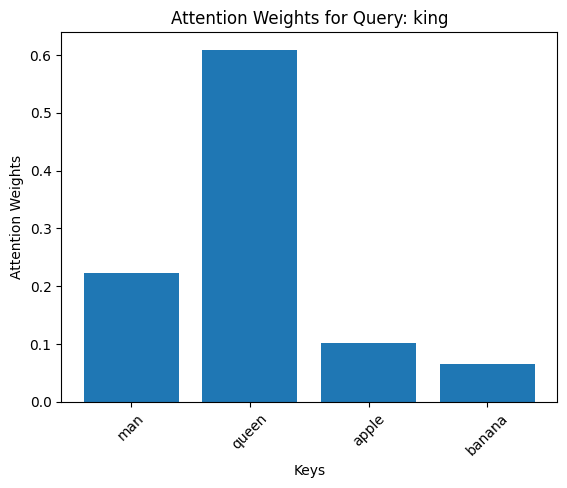

In [7]:
# plot bar chart of attention weights
import matplotlib.pyplot as plt

plt.bar(key_words, attention_weights.ravel())
plt.xlabel('Keys')
plt.ylabel('Attention Weights')
plt.title('Attention Weights for Query: ' + query_word)
plt.xticks(rotation=45)
plt.show()

In [8]:
# computing context vector
context_vector = np.dot(attention_weights, V)  # shape (1, d)

print(f"Context vector shape: {context_vector.shape}, for query '{query_word}': {context_vector.flatten()[:5]}...")  # show first 5 elements

Context vector shape: (1, 100), for query 'king': [-0.30568263 -0.36264536  0.50330895  0.27456844  0.17220724]...
